# UNSW-NB15 — Data Exploration
Understanding the dataset before building the pipeline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')

train = pd.read_parquet('../data/raw/UNSW_NB15/UNSW_NB15_training-set.parquet')
test  = pd.read_parquet('../data/raw/UNSW_NB15/UNSW_NB15_testing-set.parquet')

print('Train shape:', train.shape)
print('Test shape :', test.shape)

Train shape: (175341, 36)
Test shape : (82332, 36)


## 1. Basic Info

In [2]:
train.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


In [3]:
train.dtypes

dur                   float32
proto                category
service              category
state                category
spkts                   int16
dpkts                   int16
sbytes                  int32
dbytes                  int32
rate                  float32
sload                 float32
dload                 float32
sloss                   int16
dloss                   int16
sinpkt                float32
dinpkt                float32
sjit                  float32
djit                  float32
swin                    int16
stcpb                   int64
dtcpb                   int64
dwin                    int16
tcprtt                float32
synack                float32
ackdat                float32
smean                   int16
dmean                   int16
trans_depth             int16
response_body_len       int32
ct_src_dport_ltm         int8
ct_dst_sport_ltm         int8
is_ftp_login             int8
ct_ftp_cmd               int8
ct_flw_http_mthd         int8
is_sm_ips_

In [4]:
train.describe()

,dur,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,...,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,175341.000000,1.753410e+05,1.753410e+05,175341.000000,175341.000000,...,175341.000000,175341.000000,1.753410e+05,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,95406.179688,7.345403e+07,6.712056e+05,4.953000,6.948010,...,124.173382,0.105982,2.144292e+03,5.383538,4.206255,0.014948,0.014948,0.133066,0.015752,0.680622
std,6.480249,136.887597,110.258271,1.747656e+05,1.436542e+05,165400.968750,1.883574e+08,2.421312e+06,66.005059,52.732999,...,258.317056,0.776911,5.420797e+04,8.047104,5.783585,0.126048,0.126048,0.701208,0.124516,0.466237
min,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,32.786140,1.305334e+04,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3225.806641,8.796748e+05,1.447023e+03,0.000000,0.000000,...,44.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,125000.000000,8.888889e+07,2.784487e+04,3.000000,2.000000,...,89.000000,0.000000,0.000000e+00,5.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1000000.000000,5.988000e+09,2.242273e+07,4803.000000,5484.000000,...,1458.000000,172.000000,6.558056e+06,51.000000,46.000000,4.000000,4.000000,30.000000,1.000000,1.000000


## 2. Missing Values

In [5]:
missing = train.isnull().sum()
missing = missing[missing > 0]
print('Columns with missing values:')
print(missing if len(missing) > 0 else 'None — dataset is clean')

Columns with missing values:
None — dataset is clean


## 3. Class Distribution — attack_cat

In [6]:
print('Attack category distribution (train):')
print(train['attack_cat'].value_counts())
print()
print('As percentages:')
print((train['attack_cat'].value_counts(normalize=True) * 100).round(2))

Attack category distribution (train):
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

As percentages:
attack_cat
Normal            31.94
Generic           22.81
Exploits          19.04
Fuzzers           10.37
DoS                6.99
Reconnaissance     5.98
Analysis           1.14
Backdoor           1.00
Shellcode          0.65
Worms              0.07
Name: proportion, dtype: float64


C:\Users\abhis\AppData\Local\Temp\ipykernel_19580\3815080386.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, y='attack_cat', order=order, palette='viridis', ax=axes[0])


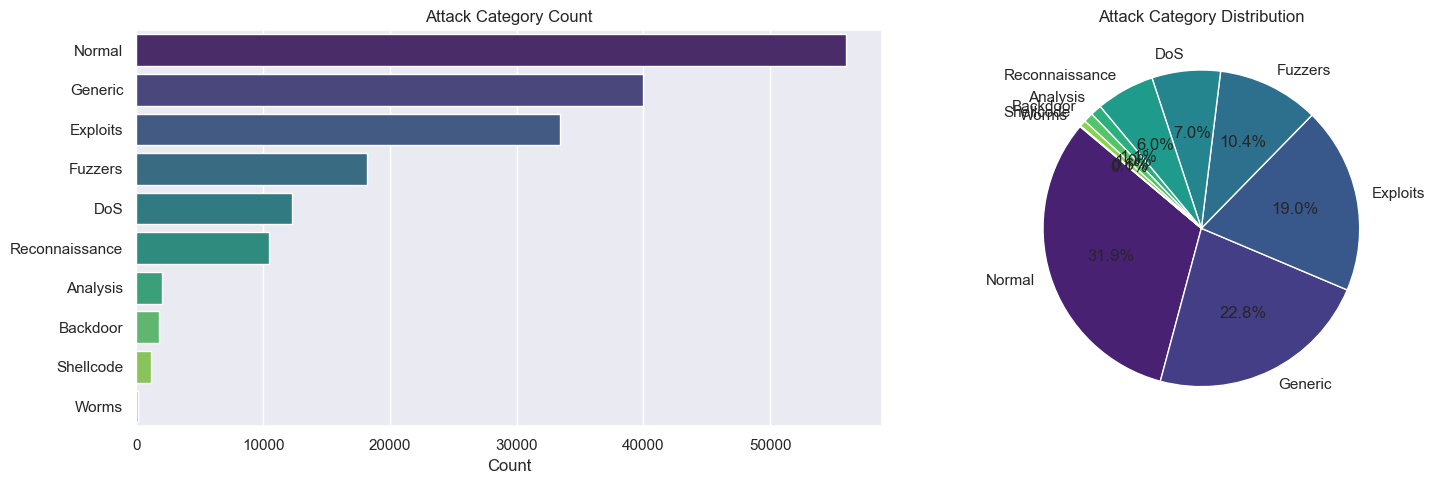

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Count plot
order = train['attack_cat'].value_counts().index
sns.countplot(data=train, y='attack_cat', order=order, palette='viridis', ax=axes[0])
axes[0].set_title('Attack Category Count')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('')

# Pie chart
counts = train['attack_cat'].value_counts()
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(counts)))
axes[1].set_title('Attack Category Distribution')

plt.tight_layout()
plt.savefig('../data/processed/attack_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Binary Label Distribution

In [8]:
print('Binary label (0=Normal, 1=Attack):')
print(train['label'].value_counts())
print()
normal_pct = (train['label'] == 0).mean() * 100
attack_pct = (train['label'] == 1).mean() * 100
print(f'Normal:  {normal_pct:.1f}%')
print(f'Attack:  {attack_pct:.1f}%')

Binary label (0=Normal, 1=Attack):
label
1    119341
0     56000
Name: count, dtype: int64

Normal:  31.9%
Attack:  68.1%


## 5. Categorical Features — Unique Values

In [9]:
cat_cols = train.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['attack_cat']]
print('Categorical columns:', cat_cols)
print()
for col in cat_cols:
    print(f'{col} ({train[col].nunique()} unique):', train[col].unique())

Categorical columns: []



## 6. Numeric Feature Distributions

In [10]:
num_cols = train.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'label']
print(f'Numeric features ({len(num_cols)}):', num_cols)

Numeric features (31): ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports']


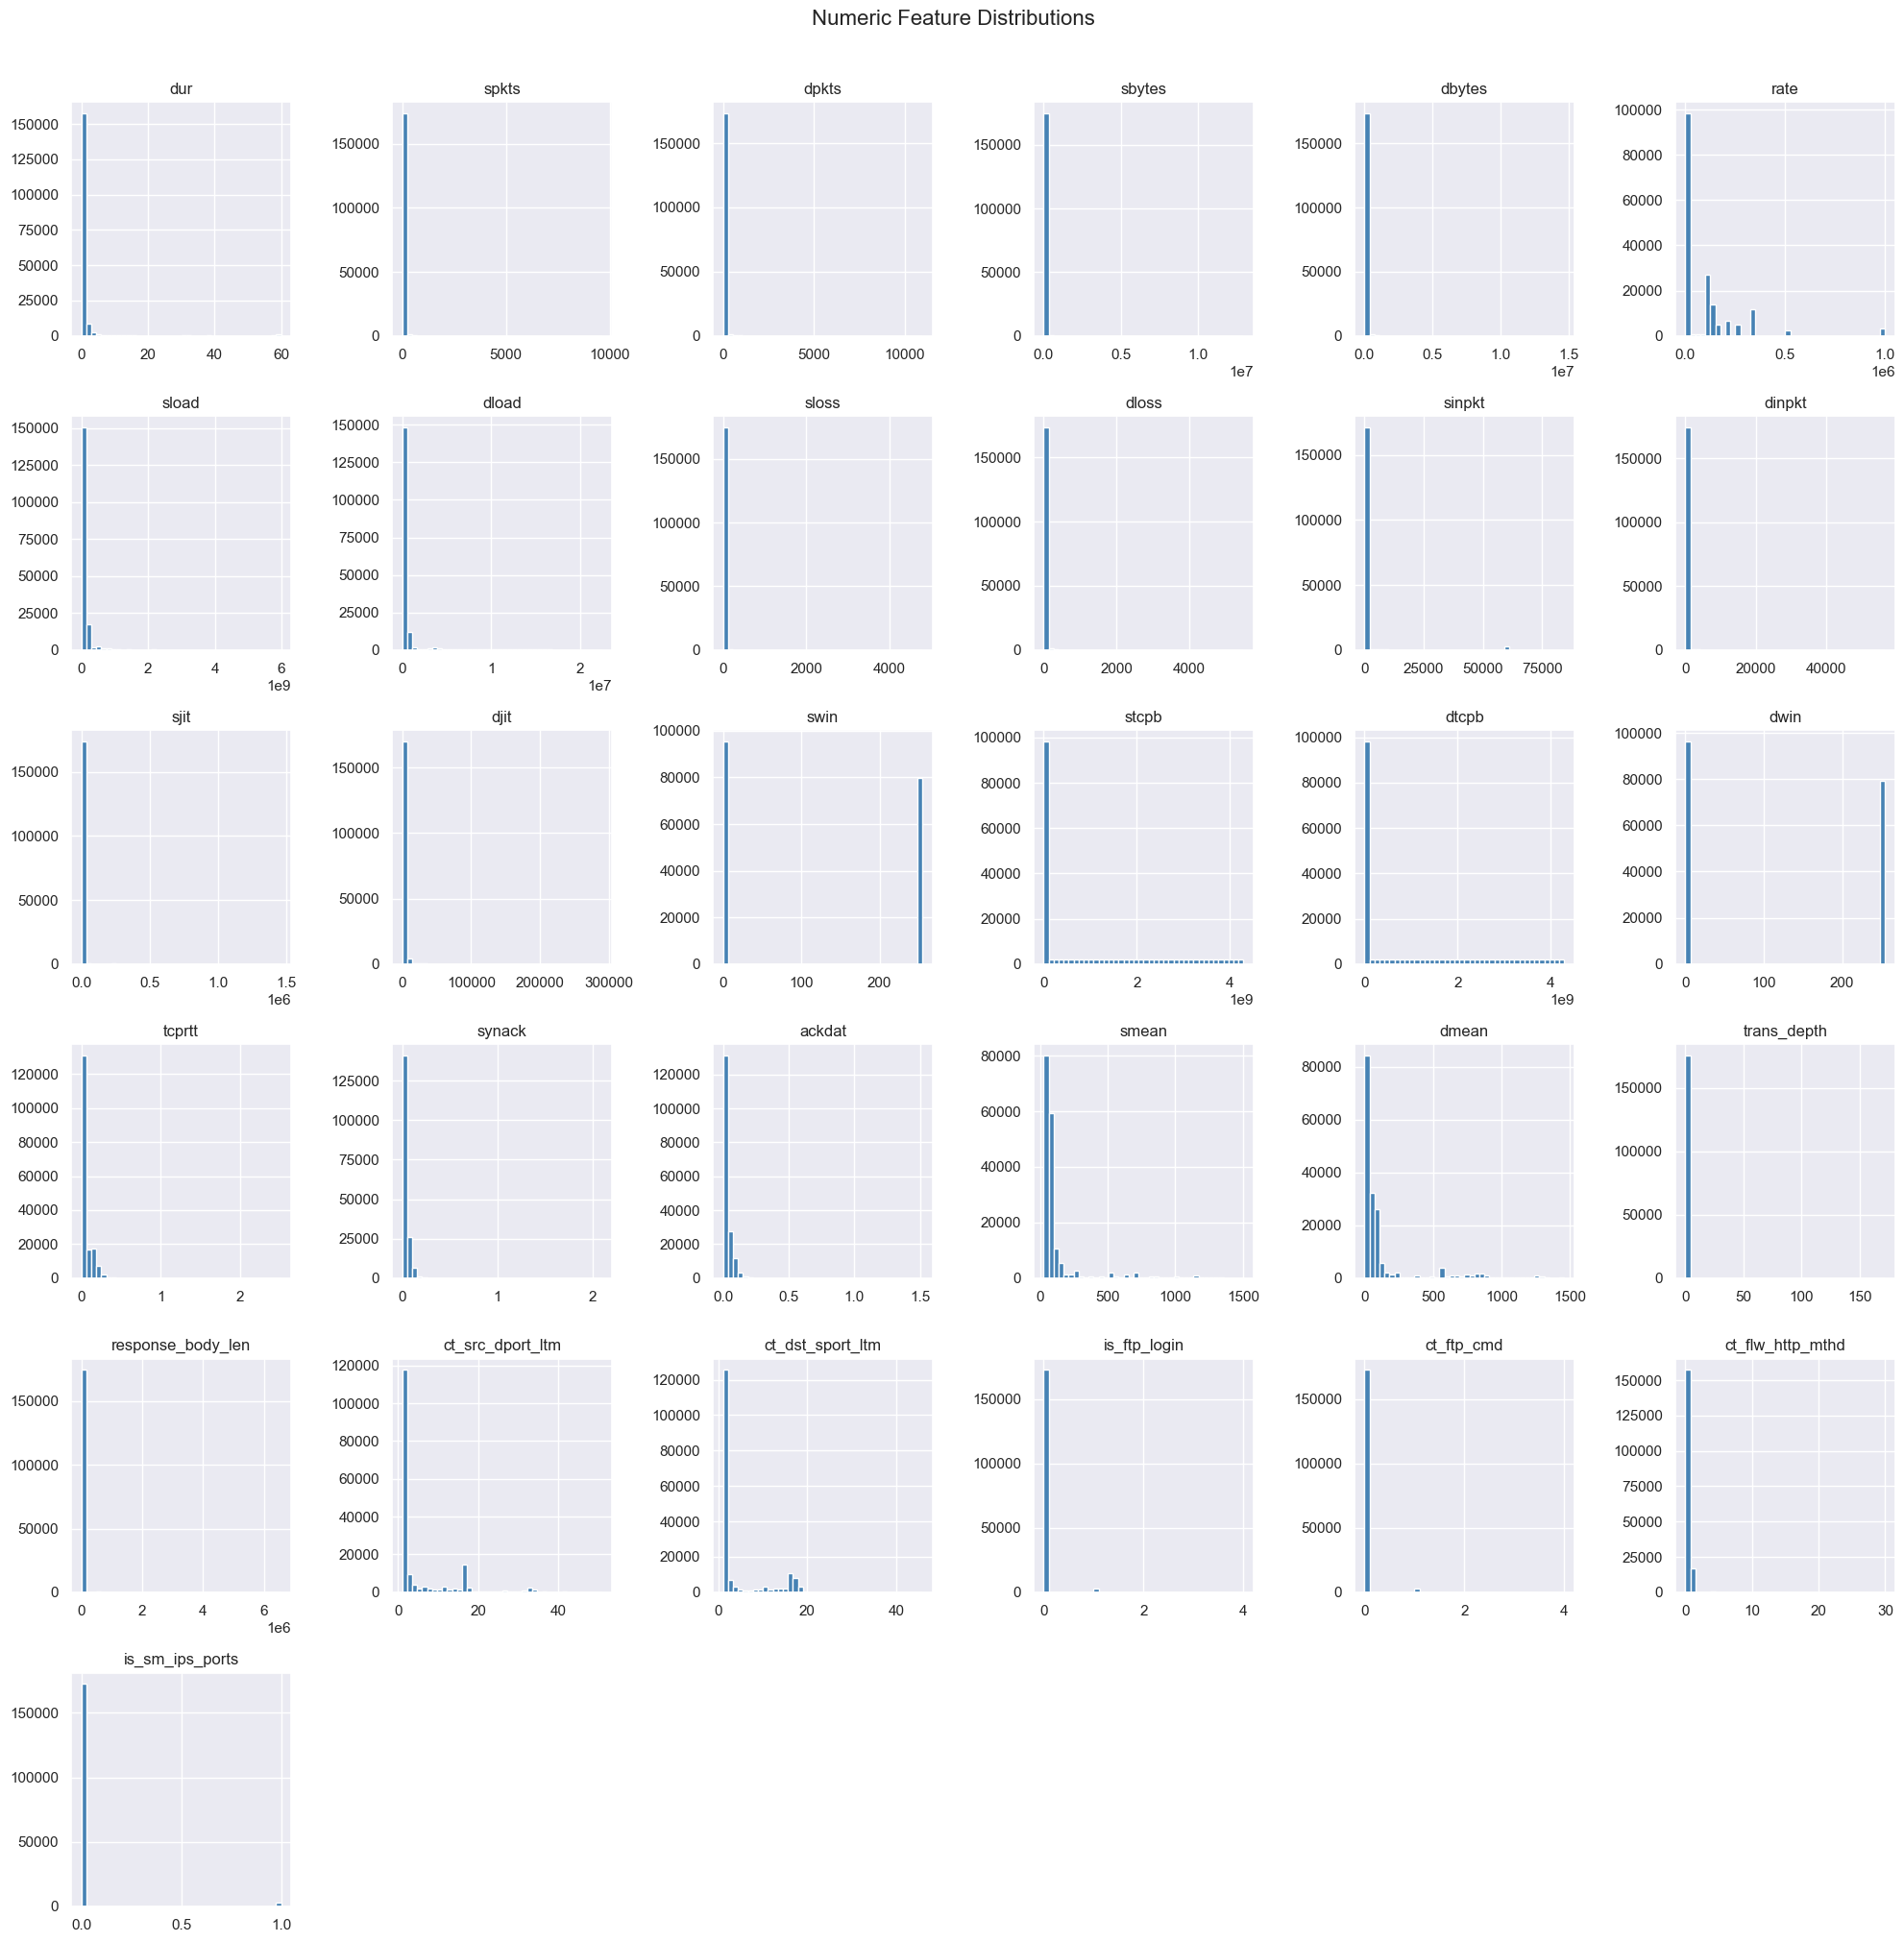

In [11]:
train[num_cols].hist(bins=40, figsize=(20, 20), color='steelblue', edgecolor='white')
plt.suptitle('Numeric Feature Distributions', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Correlation Heatmap

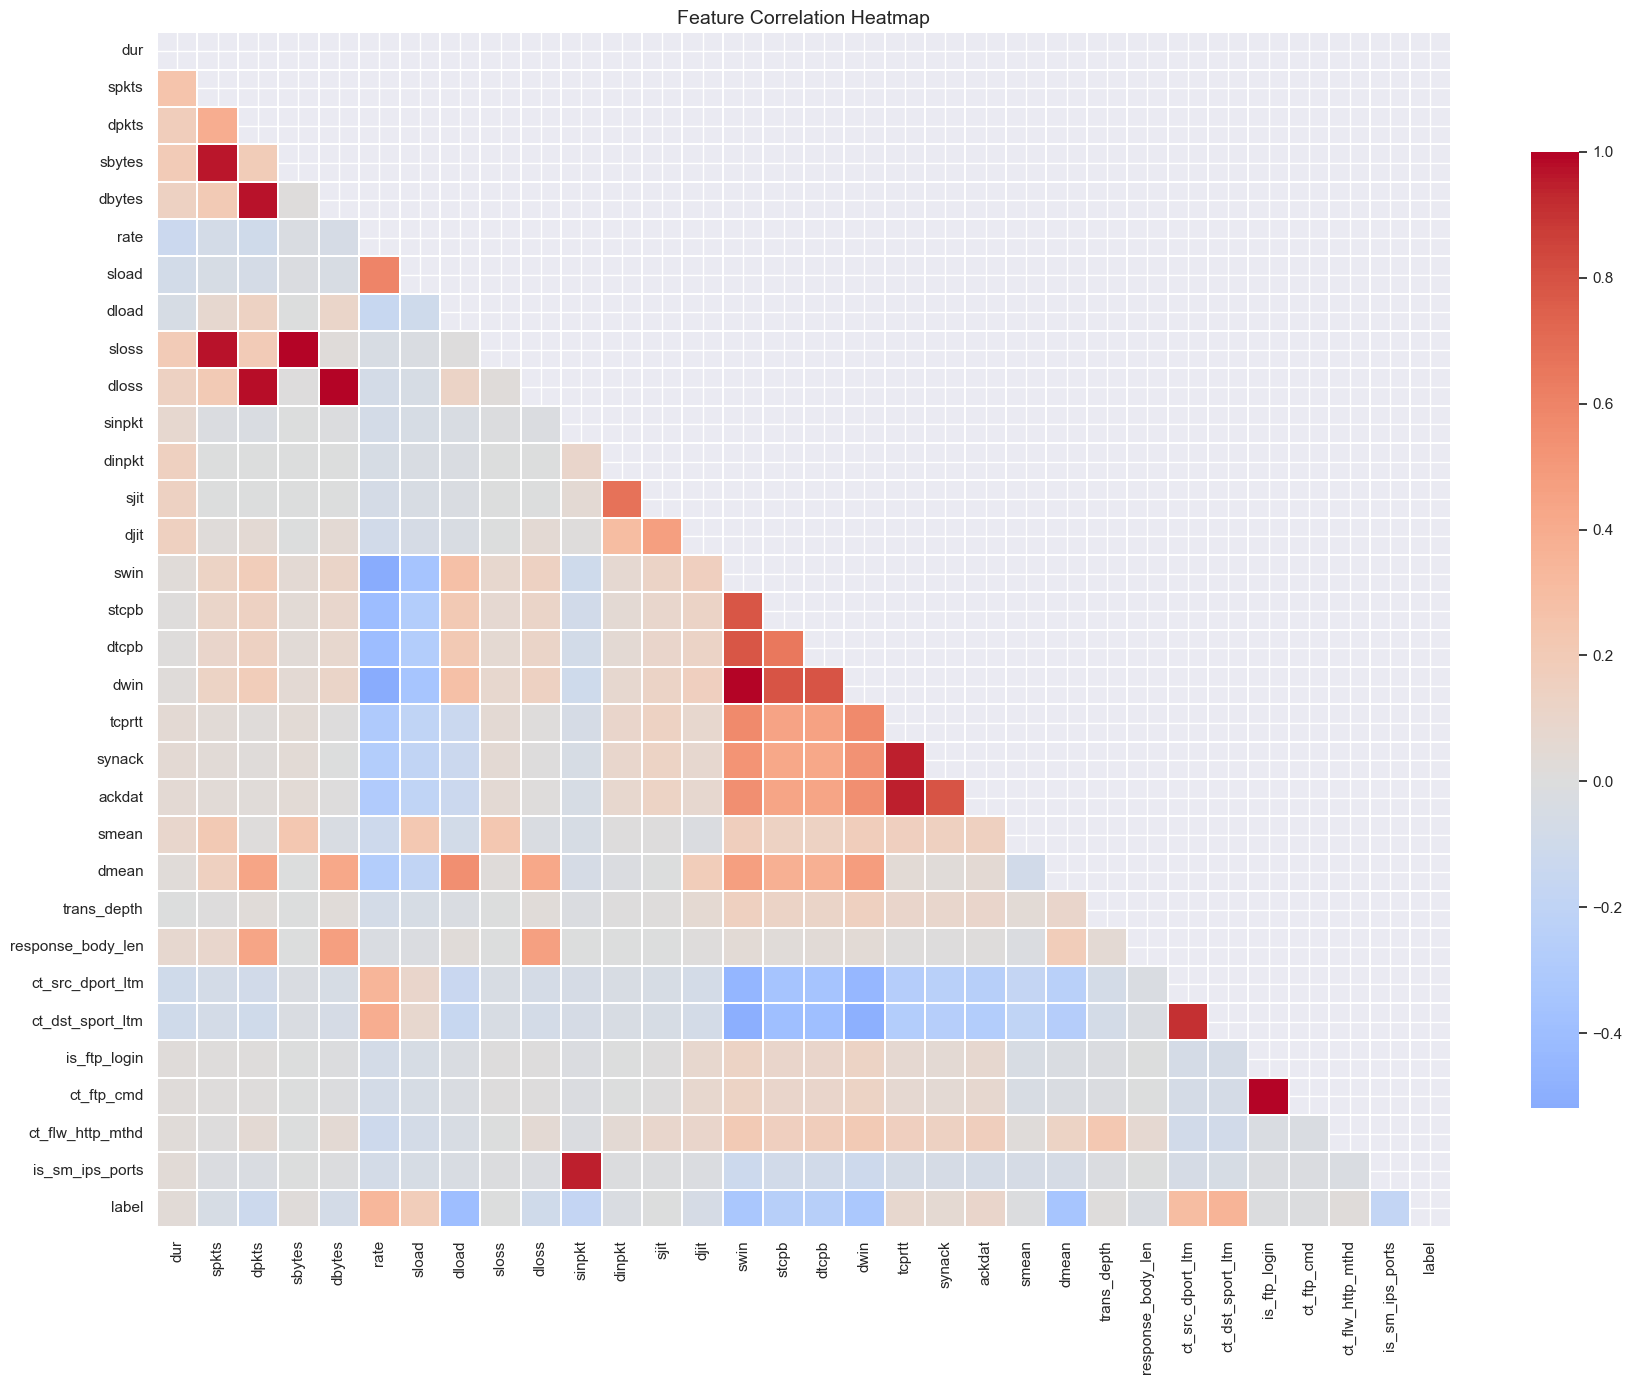

In [12]:
plt.figure(figsize=(18, 14))
corr = train[num_cols + ['label']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('../data/processed/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Features Most Correlated With Label

Top 15 features most correlated with label:
dload               0.393739
ct_dst_sport_ltm    0.357213
dmean               0.341806
rate                0.337979
swin                0.333633
dwin                0.319626
ct_src_dport_ltm    0.305579
stcpb               0.255006
dtcpb               0.250340
is_sm_ips_ports     0.184679
sload               0.182870
sinpkt              0.176110
dpkts               0.118591
ackdat              0.097364
dloss               0.094685
Name: label, dtype: float64


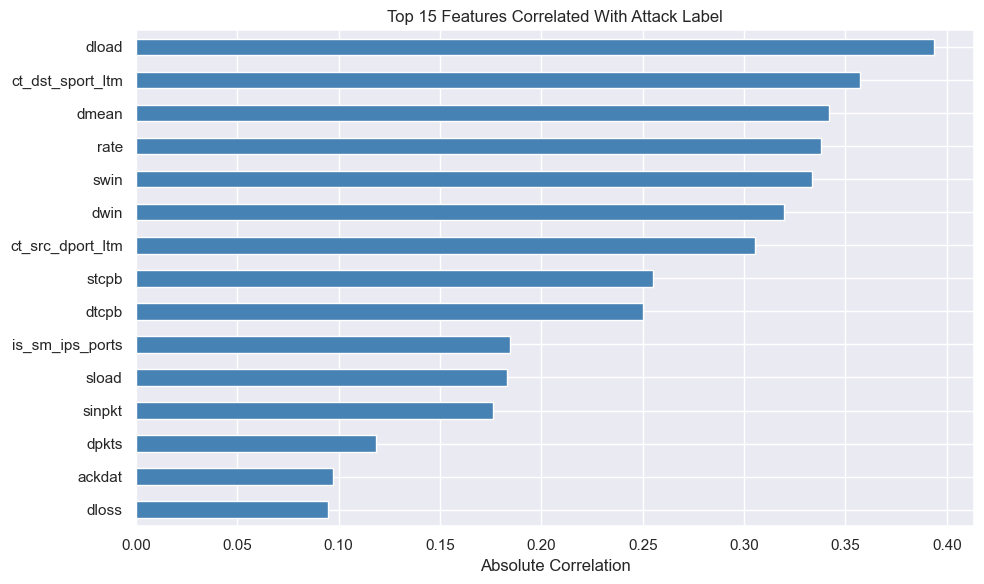

In [13]:
label_corr = corr['label'].drop('label').abs().sort_values(ascending=False)
print('Top 15 features most correlated with label:')
print(label_corr.head(15))

plt.figure(figsize=(10, 6))
label_corr.head(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 Features Correlated With Attack Label')
plt.xlabel('Absolute Correlation')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/processed/label_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Attack Category vs Key Features

C:\Users\abhis\AppData\Local\Temp\ipykernel_19580\3712567090.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data = train.groupby('attack_cat')[col].median().sort_values(ascending=False)
C:\Users\abhis\AppData\Local\Temp\ipykernel_19580\3712567090.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data = train.groupby('attack_cat')[col].median().sort_values(ascending=False)


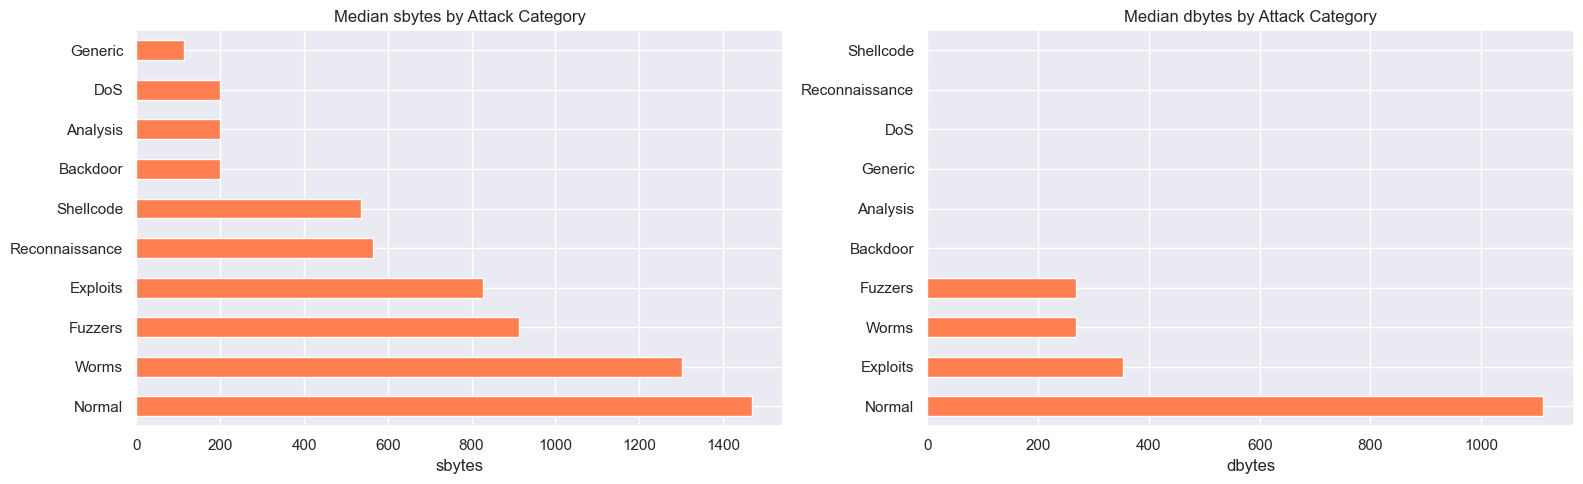

In [14]:
# Compare sbytes and dbytes across attack categories
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col in zip(axes, ['sbytes', 'dbytes']):
    data = train.groupby('attack_cat')[col].median().sort_values(ascending=False)
    data.plot(kind='barh', ax=ax, color='coral')
    ax.set_title(f'Median {col} by Attack Category')
    ax.set_xlabel(col)
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('../data/processed/attack_bytes_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Protocol Distribution by Attack Type

C:\Users\abhis\AppData\Local\Temp\ipykernel_19580\2415060697.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


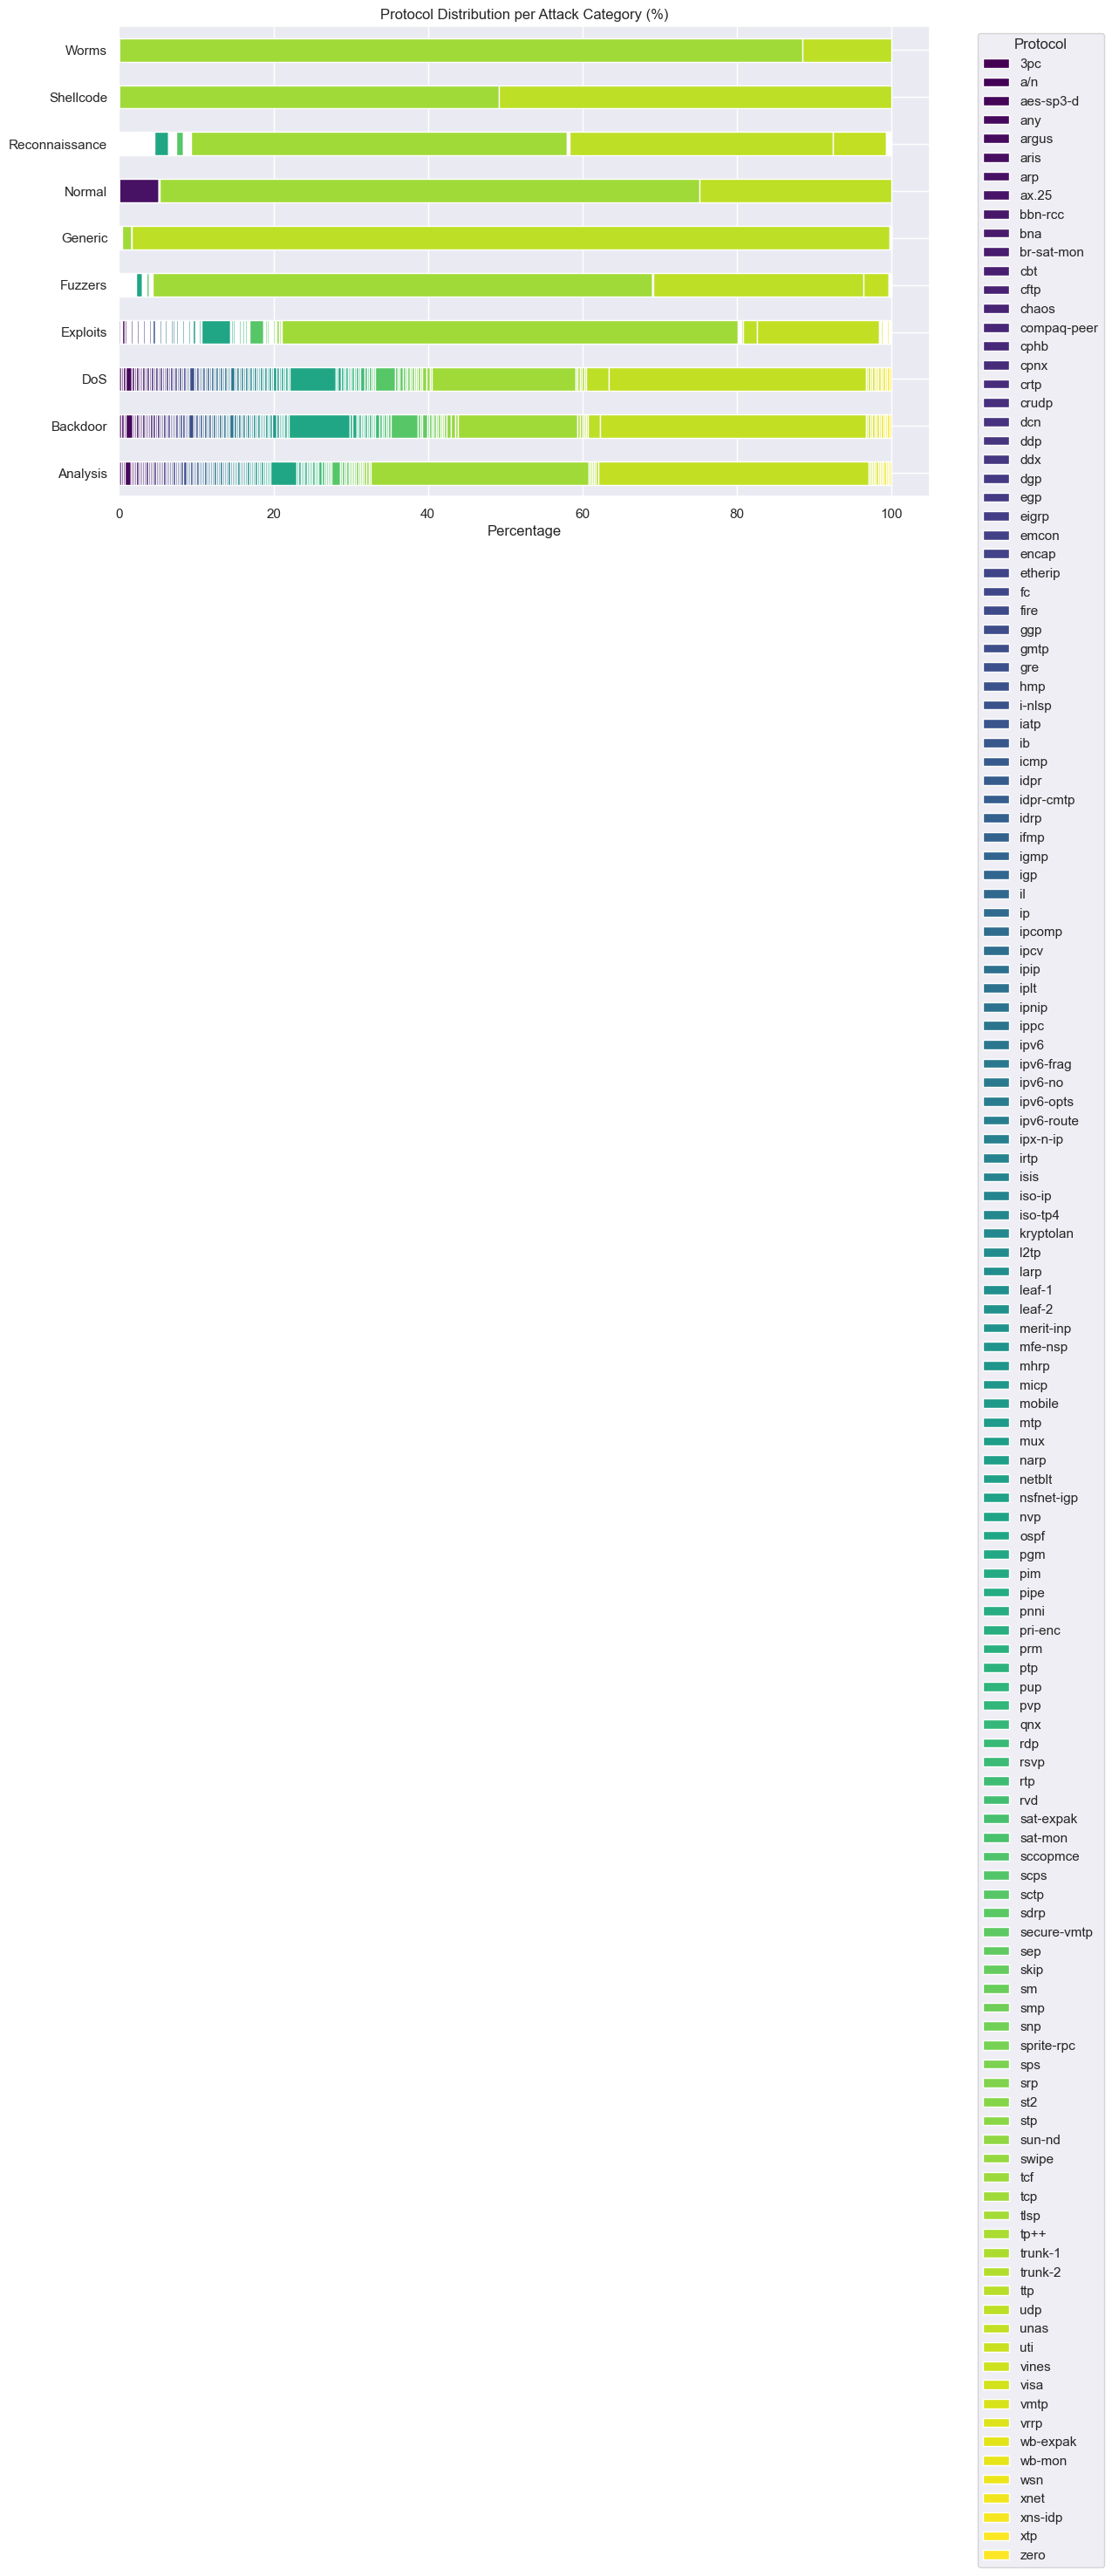

In [15]:
proto_attack = pd.crosstab(train['attack_cat'], train['proto'])
proto_attack_pct = proto_attack.div(proto_attack.sum(axis=1), axis=0) * 100

proto_attack_pct.plot(kind='barh', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Protocol Distribution per Attack Category (%)')
plt.xlabel('Percentage')
plt.ylabel('')
plt.legend(title='Protocol', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../data/processed/protocol_by_attack.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Duplicate Check

In [16]:
dupes = train.duplicated().sum()
print(f'Duplicate rows in training set: {dupes}')
print(f'That is {dupes/len(train)*100:.2f}% of the data')

Duplicate rows in training set: 78519
That is 44.78% of the data


## 12. Summary — What We Know

In [17]:
print('=' * 50)
print('DATASET SUMMARY')
print('=' * 50)
print(f'Training rows    : {len(train):,}')
print(f'Testing rows     : {len(test):,}')
print(f'Features         : {len(num_cols)} numeric + {len(cat_cols)} categorical')
print(f'Attack categories: {train["attack_cat"].nunique()}')
print(f'Missing values   : {train.isnull().sum().sum()}')
print(f'Duplicates       : {train.duplicated().sum()}')
print()
print('Categorical columns to encode:', cat_cols)
print()
print('Class distribution:')
print(train['attack_cat'].value_counts())
print('=' * 50)
print('Ready to preprocess.')

DATASET SUMMARY
Training rows    : 175,341
Testing rows     : 82,332
Features         : 31 numeric + 0 categorical
Attack categories: 10
Missing values   : 0
Duplicates       : 78519

Categorical columns to encode: []

Class distribution:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64
Ready to preprocess.
